In [6]:
from rdkit import Chem

import pandas as pd

from chembl_structure_pipeline import standardizer

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors

import seaborn as sns
import numpy as np

from rdkit.Chem import MACCSkeys

In [2]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame({"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol)
drugbank_df.set_index("id", inplace=True)
drugbank_df

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9AB8...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9AB8...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9AB8...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9AB8...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9AB8...
...,...,...
DB13154,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
DB13155,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
DB13156,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...


In [3]:
zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=['tranche', 'SMILES'], inplace=True)
zinc_df

,source,mol
id,,
ZINCtA000001eUS8,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
ZINCpo00001BLwat,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
ZINCtz000004JjrO,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
ZINCsN000009NpXg,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
ZINCsN000009NsBY,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
...,...,...
ZINCrn00001eRwYj,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B79...
ZINCsN000009Nrlo,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B79...
ZINCtB00000oxE6f,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001E9B79...


In [4]:
mtor_df = pd.read_csv("../data/chembl_mtor_ic50.csv", delimiter=";", usecols=["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
mtor_df.set_index("id", inplace=True)
mtor_df['source'] = 'chembl'
mtor_df['mol'] = mtor_df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns=['Smiles'], inplace=True)
mtor_df

,source,mol
id,,
CHEMBL1773577,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
CHEMBL1773561,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
CHEMBL1773077,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
CHEMBL1773580,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
CHEMBL1773578,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9B29...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9C47...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9C47...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x000001E9C47...


In [5]:
structures = pd.concat([drugbank_df, zinc_df, mtor_df])

In [9]:
fp =MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles("CCCC"))

In [17]:
tuple(fp)

(0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0)

In [12]:
structures["MACCS"] = structures["mol"].apply(MACCSkeys.GenMACCSKeys)

In [54]:
sources = ["chembl", "drugbank", "zinc"]

In [56]:
maccs=[]
for source in sources:
    maccs.append(pd.DataFrame(zip(*structures[structures["source"]==source]["MACCS"])))

In [59]:
for s, m in zip(sources,maccs):
    r = [(i,s) for i,s in enumerate(list(m.sum(axis=1)))]
    r.sort(key=lambda x: x[1], reverse=True)
    print(s, r[:10])

chembl [(165, 4596), (137, 4595), (163, 4595), (161, 4591), (145, 4569), (121, 4566), (120, 4565), (156, 4557), (158, 4545), (162, 4541)]
drugbank [(164, 6512), (165, 6137), (163, 5802), (161, 5687), (159, 5682), (158, 5357), (156, 5261), (157, 5260), (162, 5179), (155, 4858)]
zinc [(161, 7153), (165, 7150), (156, 7139), (158, 7136), (164, 7092), (142, 6980), (153, 6842), (154, 6773), (117, 6716), (110, 6668)]


In [49]:
r.sort(key=lambda x: x[1], reverse=True)

[     0     1     2     3     4     5     6     7     8     9     ...  4586  \
 0       0     0     0     0     0     0     0     0     0     0  ...     0   
 1       0     0     0     0     0     0     0     0     0     0  ...     0   
 2       0     0     0     0     0     0     0     0     0     0  ...     0   
 3       0     0     0     0     0     0     0     0     0     0  ...     0   
 4       0     0     0     0     0     0     0     0     0     0  ...     0   
 ..    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
 162     1     1     1     1     1     1     1     1     1     1  ...     1   
 163     1     1     1     1     1     1     1     1     1     1  ...     1   
 164     1     1     1     1     1     1     1     1     1     1  ...     1   
 165     1     1     1     1     1     1     1     1     1     1  ...     1   
 166     0     0     0     0     0     0     0     0     0     0  ...     0   
 
      4587  4588  4589  4590  4591  4592  4593  45

<Axes: >

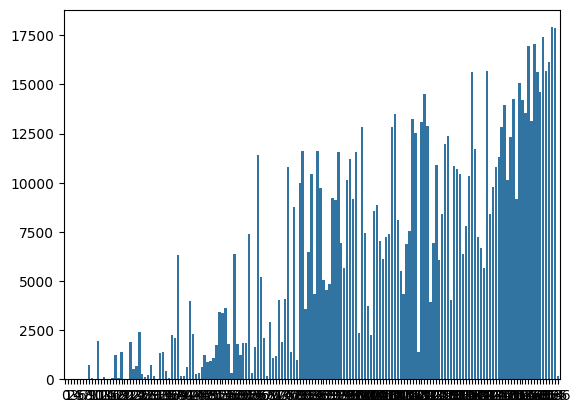

In [41]:
sns.barplot(maccs.sum(axis=1))

In [47]:
maccs

,0,1,2,3,4,5,6,7,8,9,...,18886,18887,18888,18889,18890,18891,18892,18893,18894,18895
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
163,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
164,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
165,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [60]:
from rdkit.Chem import rdFingerprintGenerator

In [73]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3)
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator()

In [84]:
mol = Chem.MolFromSmiles("CCCCCO")

In [74]:
list(morgan_gen.GetFingerprint(mol).GetOnBits()),list(rdkit_gen.GetFingerprint(mol).GetOnBits())

([80, 222, 294, 473, 591, 794, 807, 1057, 1082, 1130, 1911],
 [562,
  568,
  709,
  875,
  1118,
  1183,
  1233,
  1246,
  1308,
  1339,
  1728,
  1772,
  1813,
  1927])

In [85]:
cbv=morgan_gen.GetCountFingerprint(mol)

In [86]:
cbv.GetNonzeroElements()

{80: 4,
 222: 1,
 294: 1,
 473: 1,
 541: 1,
 591: 1,
 794: 1,
 807: 1,
 1057: 1,
 1130: 1,
 1324: 1,
 1444: 1,
 1911: 2}

In [ ]:
fp = mfpgen.GetFingerprint(ms[0])
sfp = mfpgen.GetSparseFingerprint(ms[0])

# count vectors:
cfp = mfpgen.GetCountFingerprint(ms[0])
scfp = mfpgen.GetSparseCountFingerprint(ms[0])